In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import MNIST
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

In [2]:
# Datasets & DataLoaders

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = MNIST(root="./data", train=True, download=True, transform=transform)
testset = MNIST(root="./data", train=False, download=True, transform=transform)

100%|█████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:05<00:00, 1.79MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 143kB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:03<00:00, 451kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 5.90MB/s]


In [3]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64)

In [4]:
print("Training samples:", len(trainset))
print("Testing samples:", len(testset))
print("Image shape:", trainset[0][0].shape)
print("First label:", trainset[0][1])

Training samples: 60000
Testing samples: 10000
Image shape: torch.Size([1, 28, 28])
First label: 5


# CNN

In [5]:
# Build CNN

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(7 * 7 * 64, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)

        x = x.view(x.size(0), -1)  # Flattening

        x = self.fc_layers(x)

        return x

In [6]:
model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [7]:
# Training the CNN

epochs = 10

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output = model.forward(images)  # FP

        loss = criterion(output, labels)  # loss fn
        loss.backward()  # BP
        optimizer.step()  # update params

        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")

epoch=1/10 & loss=0.1654788446843501
epoch=2/10 & loss=0.045708322694633347
epoch=3/10 & loss=0.032328227753013764
epoch=4/10 & loss=0.024581432138352583
epoch=5/10 & loss=0.016825194313868176
epoch=6/10 & loss=0.01347208373339612
epoch=7/10 & loss=0.010681465241162444
epoch=8/10 & loss=0.009753263090722608
epoch=9/10 & loss=0.008392367576965168
epoch=10/10 & loss=0.005878816659386426


In [13]:
# Evaluate our CNN

correct_labels = 0
total_labels = 0

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)

        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"CNN Accuracy = {correct_labels / total_labels * 100}")

CNN Accuracy = 99.09


# RNN

In [9]:
# Build RNN

class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()

        self.rnn = nn.RNN(
            input_size=28,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        # x shape: (batch_size, 1, 28, 28)

        x = x.squeeze(1)

        # x shape: (batch_size, 28, 28)

        output, hidden = self.rnn(x)

        # Take output from the last time step
        x = output[:, -1, :]

        x = self.fc(x)

        return x

In [10]:
model_rnn = RNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_rnn.parameters())

In [11]:
# Training the RNN

epochs = 10

for epoch in range(epochs):
    epoch_training_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        output = model_rnn.forward(images)  # FP

        loss = criterion(output, labels)  # loss fn
        loss.backward()  # BP
        optimizer.step()  # update params

        epoch_training_loss += loss.item()

    print(f"epoch={epoch+1}/{epochs} & loss={epoch_training_loss/len(trainloader)}")

epoch=1/10 & loss=0.8117253100281077
epoch=2/10 & loss=0.3686447566363222
epoch=3/10 & loss=0.2681439940386744
epoch=4/10 & loss=0.22275836473064764
epoch=5/10 & loss=0.2042100022989772
epoch=6/10 & loss=0.1835257414061187
epoch=7/10 & loss=0.16402155308545366
epoch=8/10 & loss=0.16069398297548992
epoch=9/10 & loss=0.13886014097479424
epoch=10/10 & loss=0.13793854628489025


In [12]:
# Evaluate our RNN

correct_labels = 0
total_labels = 0

model_rnn.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model_rnn.forward(images)

        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"RNN Accuracy = {correct_labels / total_labels * 100}")

RNN Accuracy = 96.69


# Visualization CNN

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

actual_labels_cnn = []
predicted_labels_cnn = []

model.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs, 1)

        actual_labels_cnn.extend(labels.numpy())
        predicted_labels_cnn.extend(predicted.numpy())

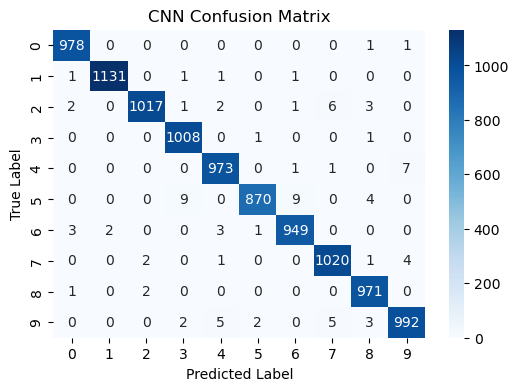

In [19]:
cm_cnn = confusion_matrix(actual_labels_cnn, predicted_labels_cnn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.show()

# Visualization RNN

In [20]:
actual_labels_rnn = []
predicted_labels_rnn = []

model_rnn.eval()

with torch.no_grad():
    for images, labels in testloader:
        outputs = model_rnn.forward(images)
        _, predicted = torch.max(outputs, 1)

        actual_labels_rnn.extend(labels.numpy())
        predicted_labels_rnn.extend(predicted.numpy())

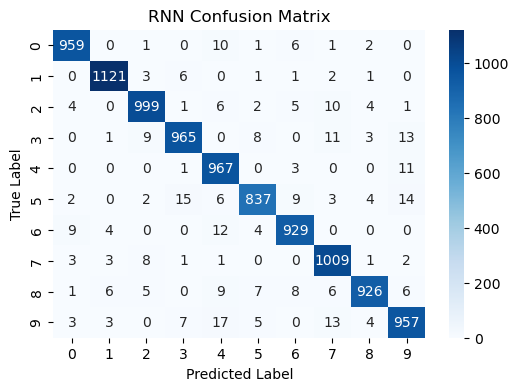

In [21]:
cm_rnn = confusion_matrix(actual_labels_rnn, predicted_labels_rnn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rnn, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("RNN Confusion Matrix")

plt.show()

## CNN vs RNN Comparison

| Aspect | CNN | RNN |
|---|---|---|
| Input representation | 28 × 28 image | 28 rows × 28 features |
| Main architecture | Convolution + Pooling | Recurrent layer |
| Hidden size / filters | 32, 64 filters | 128 hidden units |
| Output classes | 10 | 10 |
| Accuracy | 99.09% | 96.69% |
| Best suited for | Image / spatial data | Sequential data |

### Observation

The CNN achieved 99.09% accuracy, while the RNN achieved 96.69% accuracy.

The CNN performed better because it can directly learn spatial features such as edges, curves, and local patterns from the 2D image. The RNN processes the image row by row as a sequence, allowing it to learn dependencies between rows but making it less effective at capturing 2D spatial relationships.

Therefore, CNN is more suitable for handwritten digit classification.